## 1. Случайные величины

Построим плотность распределения случайной величины $X\sim U[0, 360]$.

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

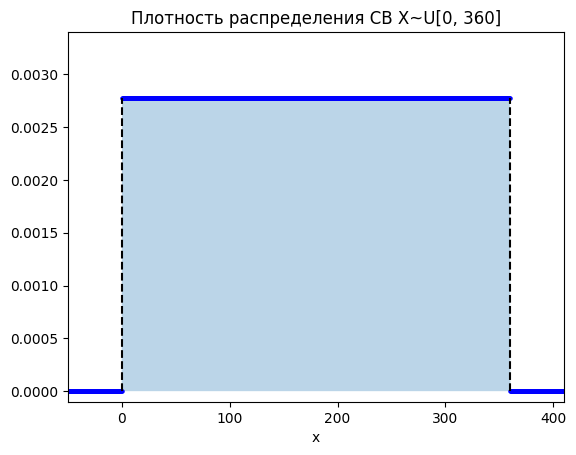

In [ ]:
X = np.linspace(-50, 410, 1000) #np.linspace(start, stop, num) создаёт массив из num равномерно расположенных чисел от start до stop.
Y = stats.uniform.pdf(X, scale=360)
# stats.uniform — равномерное распределение из scipy.stats.
# .pdf() означает Probability Density Function, то есть функция плотности вероятности.
# scale=360 задаёт длину интервала. loc — начало распределения,
plt.fill_between(X, Y, alpha=0.3) # fill_between закрашивает область между графиком Y и осью x. alpha=0.3 задаёт прозрачность:
plt.vlines([0, 360], 0, 1/360, 'k', '--')
# vlines рисует вертикальные линии.
# plt.vlines(x, ymin, ymax, ...). В matplotlib буква k означает black.
plt.scatter(X, Y, s=5, c='b') # scatter строит график из отдельных точек. задаёт размер точек. s = size. b = blue, то есть синий.
plt.xlim([-50, 410])
#xlim устанавливает отображаемые границы оси x. −50≤x≤410.
plt.ylim([-0.0001, 0.0034])
plt.xlabel('x')
plt.title('Плотность распределения СВ X~U[0, 360]');

Построим функцию распределения случайной величины $X\sim U[0, 360]$.

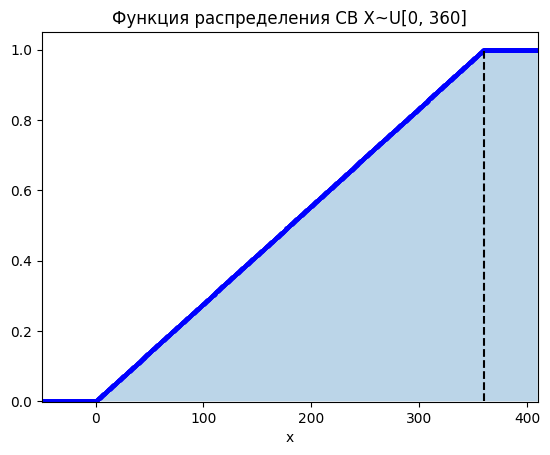

In [ ]:
X = np.linspace(-50, 410, 1000) # Создаем 1000 значений
Y = stats.uniform.cdf(X, scale=360) #cdf — cumulative distribution function, функция распределения:/ Для каждого значения считает соответствующий у
plt.fill_between(X, Y, alpha=0.3)
plt.vlines(360, 0, 1, 'k', '--')
plt.scatter(X, Y, s=5, c='b') # Рисует множество точек (Х, У)
plt.xlim([-50, 410])
plt.ylim([-0.001, 1.05])
plt.xlabel('x')
plt.title('Функция распределения СВ X~U[0, 360]');

Построим нормальные распределения с разными параметрами.

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5271/2199701421.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(X, Y, label=f'$\mu$={loc}, $\sigma$={scale}')
/tmp/ipykernel_5271/2199701421.py:6: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X, Y, label=f'$\mu$={loc}, $\sigma$={scale}')
/tmp/ipykernel_5271/2199701421.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(X, Y, label=f'$\mu$={loc}, $\sigma$={scale}')
/tmp/ipykernel_5271/2199701421.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X, Y, label=f'$\mu$={loc}, $\sigma$={scale}')


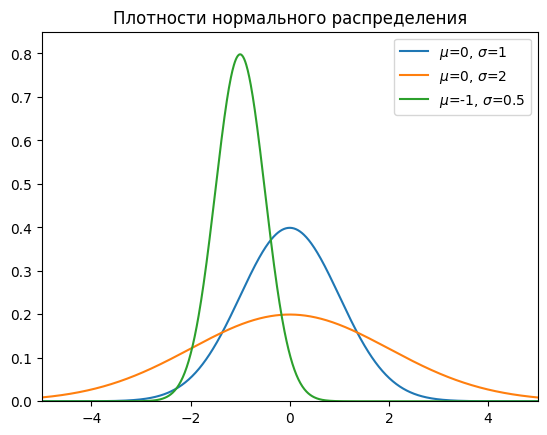

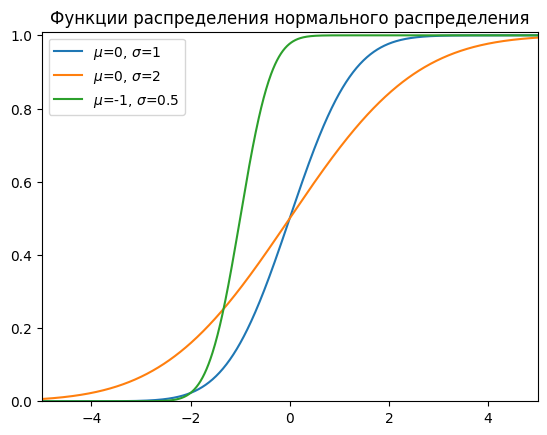

In [ ]:
-params = [(0, 1), (0, 2), (-1, 0.5)]
#  список кортежей (loc, scale). Для нормального распределения:
# loc = μ, scale = σ
# то есть: loc — математическое ожидание μ, центр распределения; scale — стандартное отклонение σ, отвечает за ширину.

X = np.linspace(-5, 5, 1000)
for loc, scale in params:
    Y = stats.norm.pdf(X, loc=loc, scale=scale)
    plt.plot(X, Y, label=f'$\mu$={loc}, $\sigma$={scale}')
plt.xlim([-5, 5])
plt.ylim([0, 0.85])
plt.title('Плотности нормального распределения')
plt.legend()
plt.show()

for loc, scale in params:
    Y = stats.norm.cdf(X, loc=loc, scale=scale)
    plt.plot(X, Y, label=f'$\mu$={loc}, $\sigma$={scale}')
plt.xlim([-5, 5])
plt.ylim([0, 1.01])
plt.title('Функции распределения нормального распределения')
plt.legend();

Построим плотности некоторых других непрерывных распределений.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=[12, 8])
fig.subplots_adjust(hspace=0.3, wspace=0.3)

params = [
    [
        axes[0, 0], stats.beta, [0, 1], 'Бета распределение',
        [{'a': 0.5, 'b': 0.5}, {'a': 2, 'b': 2}, {'a': 4, 'b': 1}]
    ],
    [
        axes[0, 1], stats.expon, [0, 10], 'Экспоненциальное распределение',
        [{'scale': 0.5}, {'scale': 1}, {'scale': 2}]
    ],
    [
        axes[1, 0], stats.chi2, [0, 10], 'Хи-квадрат распределение',
        [{'df': 2}, {'df': 3}, {'df': 5}]
    ],
    [

        axes[1, 1], stats.laplace, [-7, 7], 'Лапласа распределение',
        [{'scale': 1}, {'scale': 2}, {'scale': 4}]
    ],
]

for ax, dist, xlim, name, dist_params in params:
    X = np.linspace(xlim[0], xlim[1], 1000)
    maxY = 0
    for dist_param in dist_params:
        Y = dist.pdf(X, **dist_param)
        maxY = max(max(Y[Y < np.inf]), maxY)
        ax.plot(X, Y, label=f'{dist_param}')
    ax.set_xlim(xlim)
    ax.set_ylim([0, maxY])
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.legend()
plt.plot();

NameError: name 'plt' is not defined

## 2. Характеристики случайных величин

Вычислим среднее, дисперсию и квантиль для случайной величины из равномерного распределения.

In [ ]:
a, b = 5, 15
mean_ = stats.uniform(loc=a, scale=b-a).mean()
var_ = stats.uniform(loc=a, scale=b-a).var()
q = stats.uniform(loc=a, scale=b-a).ppf(0.9)
mean_, var_, q

(np.float64(10.0), np.float64(8.333333333333332), np.float64(14.0))

Изобразим квантиль на графике для нормального распределения.

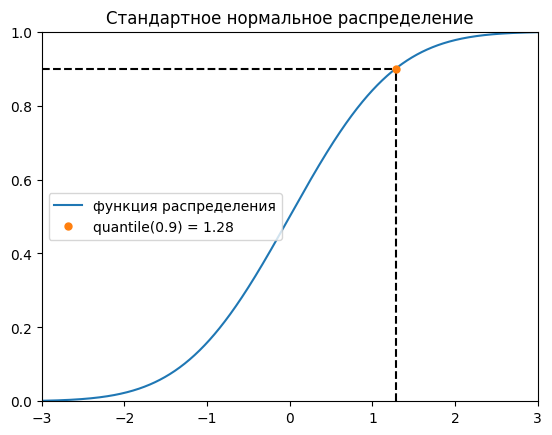

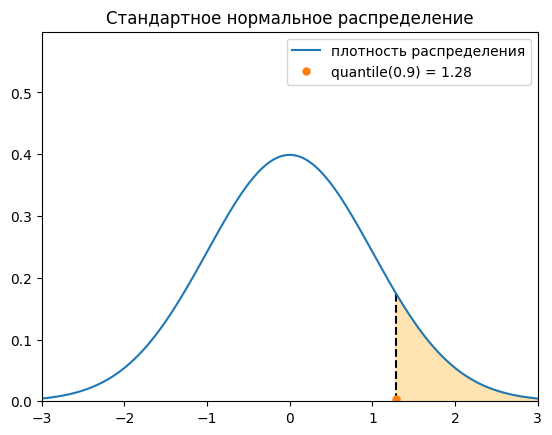

In [ ]:
X = np.linspace(-3, 3, 1000)
Y = stats.norm.cdf(X)

alpha = 0.9
q = stats.norm.ppf(alpha)
plt.hlines(alpha, -3, q, 'k', '--')
plt.vlines(q, 0, alpha, 'k', '--')
plt.plot(X, Y, label='функция распределения')
plt.plot([q], [alpha], 'o', markersize=5, label=f'quantile({alpha}) = {q:0.2f}')
plt.xlim([-3, 3])
plt.ylim([0, 1])
plt.legend(loc=6)
plt.title('Стандартное нормальное распределение')
plt.show()

Y = stats.norm.pdf(X)
mask = X >= q
plt.fill_between(X[mask], Y[mask], alpha=0.3, color='orange')
plt.vlines(q, 0, Y[mask][0], 'k', '--')
plt.plot(X, Y, label='плотность распределения')
plt.plot([q], [0.003], 'o', markersize=5, label=f'quantile({alpha}) = {q:0.2f}')
plt.xlim([-3, 3])
plt.ylim([0, max(Y)*1.5])
plt.legend()
plt.title('Стандартное нормальное распределение');

## 3. Генерация данных

Сгенерируем данные с помощью `numpy.random`

In [ ]:
# равномерное распределение от 0 до 1
size = 5
np.random.rand(size)

array([0.1474274 , 0.0649314 , 0.78891281, 0.96063632, 0.49140244])

In [ ]:
# равномерное целочисленное распределение
np.random.randint(1, 3, size)

array([2, 1, 1, 2, 1])

In [ ]:
# нормальное распределение
np.random.normal(10, 5, size)

array([10.93023373, 12.76641489,  6.61864262,  9.03039198,  0.96197692])

In [ ]:
# биномиальное распределение
np.random.binomial(10, 0.2, size)

array([0, 1, 2, 3, 1])

Сгенерируем данные с помощью `scipy.stats`

In [ ]:
# нормальное распределение
stats.norm.rvs(10, 1, size)

array([10.62362952,  8.5488685 ,  8.89797256, 10.20411425, 10.327071  ])

## 4. Корреляция

Сгенерируем значения для случайных величин с разными корреляциями, отобразим их на графиках.

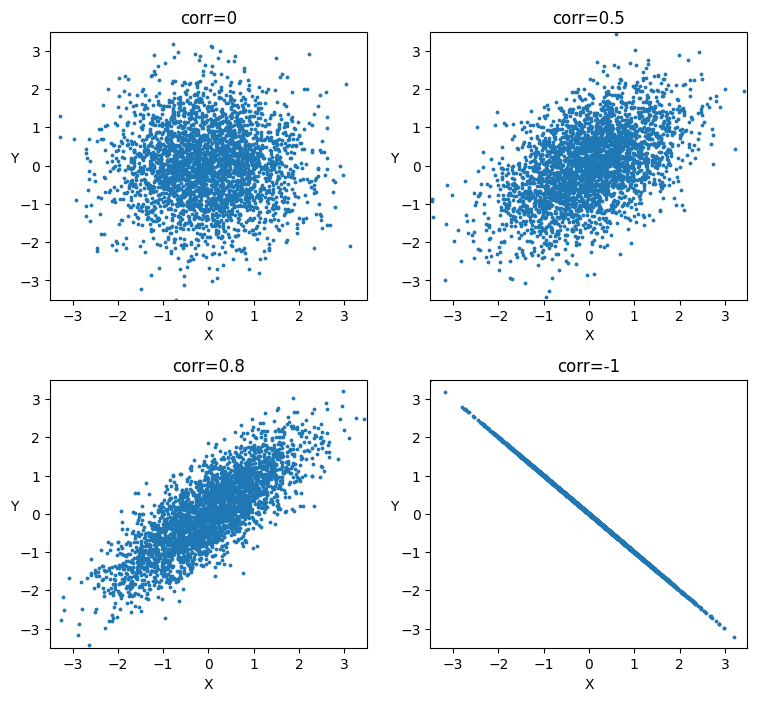

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=[9, 8])
fig.subplots_adjust(hspace=0.3)

params = [
    [axes[0, 0], 0],
    [axes[0, 1], 0.5],
    [axes[1, 0], 0.8],
    [axes[1, 1], -1],
]

for ax, corr in params:
    mean = [0, 0]
    cov = [[1, corr], [corr, 1]]
    X, Y = np.random.multivariate_normal(mean, cov, size=3000).T

    ax.scatter(X, Y, s=3)
    ax.set_xlim([-3.5, 3.5])
    ax.set_ylim([-3.5, 3.5])
    ax.set_title(f'corr={corr}')
    ax.set_ylabel('Y', rotation=0)
    ax.set_xlabel('X')
plt.plot();